In [1]:
# Importing the necessary libraries
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torchvision
import matplotlib.pyplot as plt
from torchvision import transforms
from torch.utils.data import DataLoader,TensorDataset
from torch.utils.data import Subset
from sklearn.model_selection import train_test_split
import os
from pathlib import Path

In [2]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


## Working with MNIST Dataset

In [ ]:
# Loading and preprocessing the data
image_path='./'
transform=transforms.Compose([transforms.ToTensor()])
# Loading train and test MNIST datsets
mnist_train_dataset=torchvision.datasets.MNIST(root=image_path,train=True,transform=transform,download=True)
mnist_test_dataset=torchvision.datasets.MNIST(root=image_path,train=False,transform=transform,download=True)
# Looking at one of the pictures from the train dataset
picture,label=mnist_train_dataset[0]
picture.shape
len(mnist_train_dataset) # 60000 MNIST images with labels
# Splitting train dataset into validation and train part
mnist_valid_dataset=Subset(mnist_train_dataset,torch.arange(0,10000))
mnist_train_dataset=Subset(mnist_train_dataset,torch.arange(10000,len(mnist_train_dataset)))
# DataLoaders with batches of 64 
batch_size=64
torch.manual_seed(1)
train_dl=DataLoader(mnist_train_dataset,batch_size=batch_size,shuffle=True)
valid_dl=DataLoader(mnist_valid_dataset,batch_size=batch_size,shuffle=True)
test_dl=DataLoader(mnist_test_dataset,batch_size=batch_size,shuffle=True)

# Creating a convolutional model 
# Firts convolutional layer=> 32 feature maps, second convolutional layer=> 64 feature maps
model=nn.Sequential()
model.add_module('conv1',nn.Conv2d(in_channels=1,out_channels=32,kernel_size=5, padding=2))
model.add_module('relu1',nn.ReLU())
model.add_module('pool1',nn.MaxPool2d(kernel_size=2))
model.add_module('conv2',nn.Conv2d(in_channels=32,out_channels=64,kernel_size=5,padding=2))
model.add_module('relu2',nn.ReLU())
model.add_module('pool2',nn.MaxPool2d(kernel_size=2))
# Looking at the model output 
x=torch.ones((4,1,28,28))
model(x).shape #output shape:[4,64,7,7] (batch, feature maps, height, width)
# Falttening to pass the input to Linear layer
model.add_module('flatten',nn.Flatten())
# Model output after flattening
x=torch.ones((4,1,28,28))
model(x).shape  # output shape:[4,3136] (batch,input_units)
# Adding fully connected layers with dropout layers in between 
model.add_module('fc1',nn.Linear(3136,1024))
model.add_module('relu3',nn.ReLU())
model.add_module('dropout',nn.Dropout(p=0.5))
model.add_module('fc2',nn.Linear(1024,10))
# model.add_module('sigmoid',nn.Softmax())
# Moving the model for GPU
model.to(device)

# Creating a loss function and an optimizer
loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(model.parameters(),lr=0.001)
# Looking at the model layers
model[4]

# Defining a train function for the model 
def train(model,num_epochs,train_dl,valid_dl):
    loss_hist_train=[0]*num_epochs
    loss_hist_val=[0]*num_epochs
    acc_hist_train=[0]*num_epochs
    acc_hist_val=[0]*num_epochs
    for epoch in range(num_epochs):
        model.train() # Droping the neurons during training process
        for x_batch,y_batch in train_dl:
            x_batch=x_batch.to(device)
            y_batch=y_batch.to(device)
            pred=model(x_batch)
            loss=loss_fn(pred,y_batch)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            loss_hist_train[epoch]+=loss.item()
            is_correct=(torch.argmax(pred,dim=1)==y_batch).float()
            acc_hist_train[epoch]+=is_correct.sum().item()
        # Dividing through the length of the train dataloader (number of batches) would return the average loss per sample
        loss_hist_train[epoch]/=len(train_dl)
        # Getting accuracy as a fraction after dividing through the whole dataset 
        acc_hist_train[epoch]/=len(train_dl.dataset)
        # Evaluating the model=> Dropout layer is inactive
        model.eval()
        with torch.no_grad():
            for x_batch,y_batch in valid_dl:
                x_batch=x_batch.to(device)
                y_batch=y_batch.to(device)
                pred1=model(x_batch)
                loss1=loss_fn(pred1,y_batch)
                loss_hist_val[epoch]+=loss1.item()
                is_correct=(torch.argmax(pred1,dim=1)==y_batch).float()
                acc_hist_val[epoch]+=is_correct.sum().item()
        # Dividing through the number of batches to determine loss per sample
        loss_hist_val[epoch]/=len(valid_dl)
        # Dividing through the number of samples=> to detemine accuracy as a float
        acc_hist_val[epoch]/=len(valid_dl.dataset)
        # Print accuracy and loss for every 20 epochs
        print(f'{epoch}, Training Loss: {loss_hist_train[epoch]:.3f}, Training Accuracy {acc_hist_train[epoch]:.3f},\n Valid Loss: {loss_hist_val[epoch]:.3f}, Test Accuracy: {acc_hist_val[epoch]:.3f}')
    return loss_hist_train,loss_hist_val,acc_hist_train,acc_hist_val

# Training our model 
torch.manual_seed(44)
num_epochs=50
hist=train(model,num_epochs=num_epochs,train_dl=train_dl,valid_dl=valid_dl)

0, Training Loss: 0.168, Training Accuracy 0.946,
 Valid Loss: 0.058, Test Accuracy: 0.983
1, Training Loss: 0.051, Training Accuracy 0.984,
 Valid Loss: 0.054, Test Accuracy: 0.984
2, Training Loss: 0.036, Training Accuracy 0.990,
 Valid Loss: 0.041, Test Accuracy: 0.988
3, Training Loss: 0.026, Training Accuracy 0.992,
 Valid Loss: 0.034, Test Accuracy: 0.989
4, Training Loss: 0.021, Training Accuracy 0.993,
 Valid Loss: 0.040, Test Accuracy: 0.989
5, Training Loss: 0.019, Training Accuracy 0.994,
 Valid Loss: 0.037, Test Accuracy: 0.990
6, Training Loss: 0.016, Training Accuracy 0.995,
 Valid Loss: 0.042, Test Accuracy: 0.989
7, Training Loss: 0.014, Training Accuracy 0.996,
 Valid Loss: 0.032, Test Accuracy: 0.991
8, Training Loss: 0.010, Training Accuracy 0.997,
 Valid Loss: 0.043, Test Accuracy: 0.991
9, Training Loss: 0.009, Training Accuracy 0.997,
 Valid Loss: 0.040, Test Accuracy: 0.990
10, Training Loss: 0.009, Training Accuracy 0.997,
 Valid Loss: 0.046, Test Accuracy: 0.99

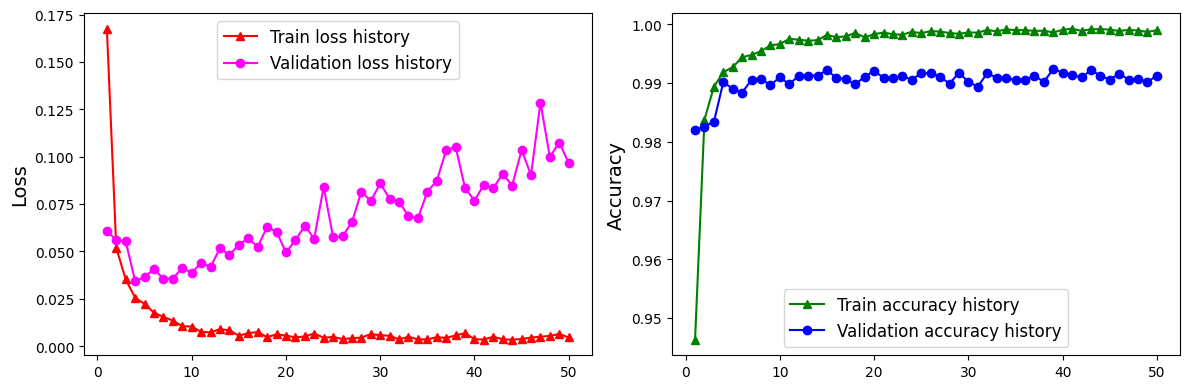

In [ ]:
# Plotting the loss as well as accuracy of train and validation datasets
fig,ax=plt.subplots(nrows=1,ncols=2,figsize=(12,4))
x=np.arange(1,num_epochs+1)
ax[0].plot(x,hist[0],color='red',marker='^',label='Train loss history')
ax[0].plot(x,hist[1],color='magenta',marker='o',label='Validation loss history')
ax[0].legend(loc='upper center',fontsize=12)
ax[0].set_ylabel('Loss',fontsize=14)
ax[1].plot(x,hist[2],color='green',marker='^',label='Train accuracy history')
ax[1].plot(x,hist[3],color='blue',marker='o',label='Validation accuracy history')
ax[1].legend(loc='lower center',fontsize=12)
ax[1].set_ylabel('Accuracy',fontsize=14)
plt.tight_layout()

In [ ]:
mnist_test_dataset.data[0]

tensor([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   

In [ ]:
# Conducting the prediction on the test dataset 
# Moving the input tensor to the GPU device
pred=model((mnist_test_dataset.data.unsqueeze(1)/255.).to(device))

In [ ]:
# Counting the proportion of correct prediction 
is_correct=(torch.argmax(pred,dim=1)==mnist_test_dataset.targets.to(device)).float()
accuracy=is_correct.sum()/len(mnist_test_dataset)
print(f'Test accuracy {accuracy:.4f}')

Test accuracy 0.9925


In [ ]:
mnist_test_dataset.data.shape

torch.Size([10000, 28, 28])

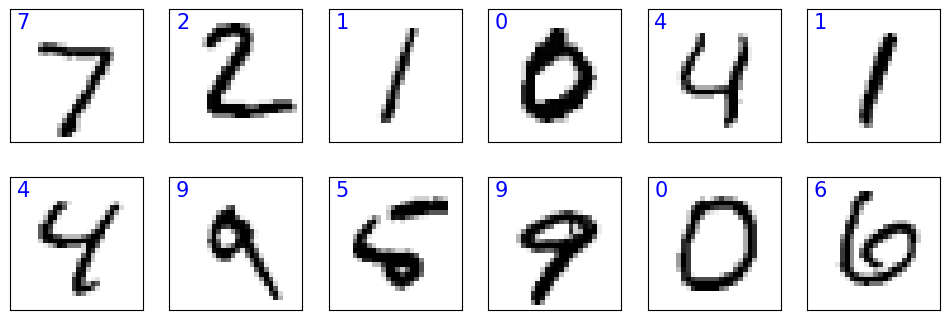

In [ ]:
# Visualizing the input and predicted labels for the batch of 12 examples
fig,ax=plt.subplots(nrows=2,ncols=6,figsize=(12,4))
ax=ax.flatten()
for i in range(12):
    ax[i].imshow(mnist_test_dataset.data[i],cmap='gray_r')
    ax[i].set_xticks([])
    ax[i].set_yticks([])
    # Adding text label based on the model prediction 
    pred=model((mnist_test_dataset.data[i].unsqueeze(0).unsqueeze(0)/255.).to(device))
    l=torch.argmax(pred,dim=1)
    ax[i].text(0.1,0.9,s=l.item(),size=15,color='blue',horizontalalignment='center',verticalalignment='center',transform=ax[i].transAxes)

## Working with CelebA Dataset

In [ ]:
# Loading CelebA dataset
image_path="./"
celeba_train_dataset=torchvision.datasets.CelebA(image_path,split="train",target_type='attr',download=False)
celeba_val_dataset=torchvision.datasets.CelebA(image_path,split="valid",target_type='attr',download=False)
celeba_test_dataset=torchvision.datasets.CelebA(image_path,split="test",target_type='attr',download=False)

In [ ]:
# Printing the length of the datasets
print('Train set', len(celeba_train_dataset))
print('Validation set', len(celeba_val_dataset))
print('Test set', len(celeba_test_dataset))

Train set 162770
Validation set 19867
Test set 19962


In [ ]:
transform=transforms.Compose([transforms.ToTensor()])
tensor=transform(celeba_train_dataset[0][0])
tensor.shape # Looking at the image shape 218*178

torch.Size([3, 218, 178])

In [ ]:
type(celeba_test_dataset[0][0])

PIL.JpegImagePlugin.JpegImageFile

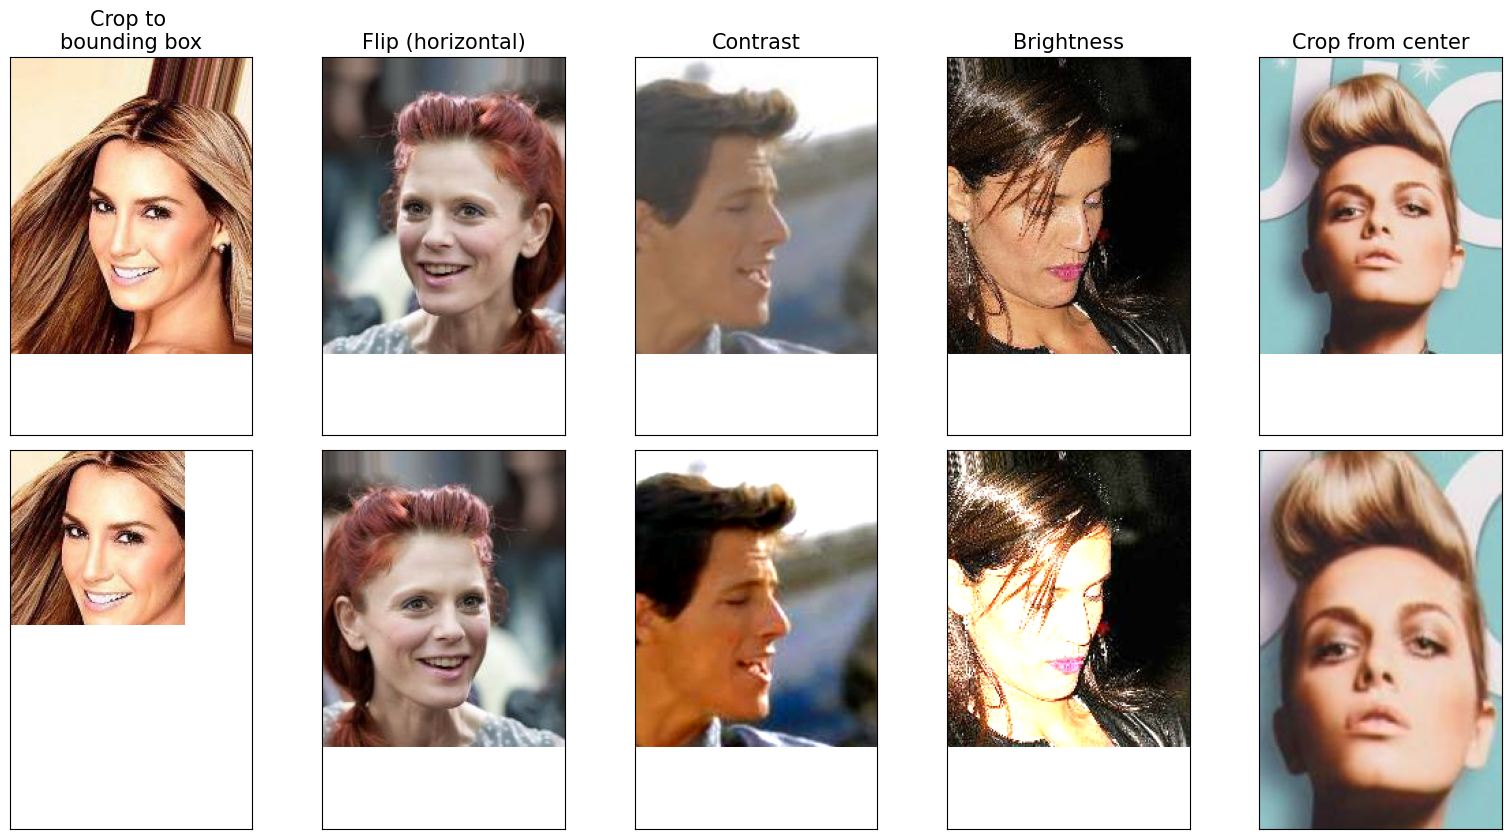

In [ ]:
# Different fata augmention for image data
fig,axes=plt.subplots(nrows=2,ncols=5,sharex=True,sharey=True,figsize=(16,8.5))
# Cropping operation 
img,attribute=celeba_train_dataset[0]
axes[0][0].set_title('Crop to \nbounding box',size=15)
axes[0][0].imshow(img)
axes[0][0].set_xticks([]),axes[0][0].set_yticks([])
cropped_img=transforms.functional.crop(img,50,20,128,128)
axes[1][0].imshow(cropped_img)
axes[1][0].set_xticks([]),axes[1][0].set_yticks([])

# Flipping horizontaly 
axes[0][1].imshow(img2)
axes[0][1].set_title('Flip (horizontal)',size=15)
axes[0][1].set_xticks([]),axes[0][1].set_yticks([])
img_flipped=transforms.functional.hflip(img2)
axes[1][1].imshow(img_flipped)
axes[1][1].set_xticks([]),axes[1][0].set_yticks([])

# Adjusting contrast 
img3,attribute=celeba_train_dataset[2]
axes[0][2].imshow(img3)
axes[0][2].set_title('Contrast',size=15)
axes[0][2].set_yticks([]),axes[0][2].set_xticks([])
cont_2=transforms.functional.adjust_contrast(img3,contrast_factor=2)
axes[1][2].imshow(cont_2)
axes[1][2].set_yticks([]),axes[1][2].set_xticks([])

# Adjusting brightness
img4,attribute=celeba_train_dataset[3]
axes[0][3].imshow(img4)
axes[0][3].set_title('Brightness',size=15)
axes[0][3].set_yticks([]),axes[0][3].set_xticks([])
bright_image=transforms.functional.adjust_brightness(img4,brightness_factor=2)
axes[1][3].imshow(bright_image)

# Croping from the center 
img5,attribute=celeba_train_dataset[4]
axes[0][4].imshow(img5)
axes[0][4].set_title('Crop from center',size=15)
axes[0][4].set_yticks([]),axes[0][4].set_xticks([])
centr_crop_img=transforms.functional.center_crop(img5,output_size=[180,130])
resized_img=transforms.functional.resize(centr_crop_img,size=(278,178))
axes[1][4].imshow(resized_img)

plt.tight_layout()

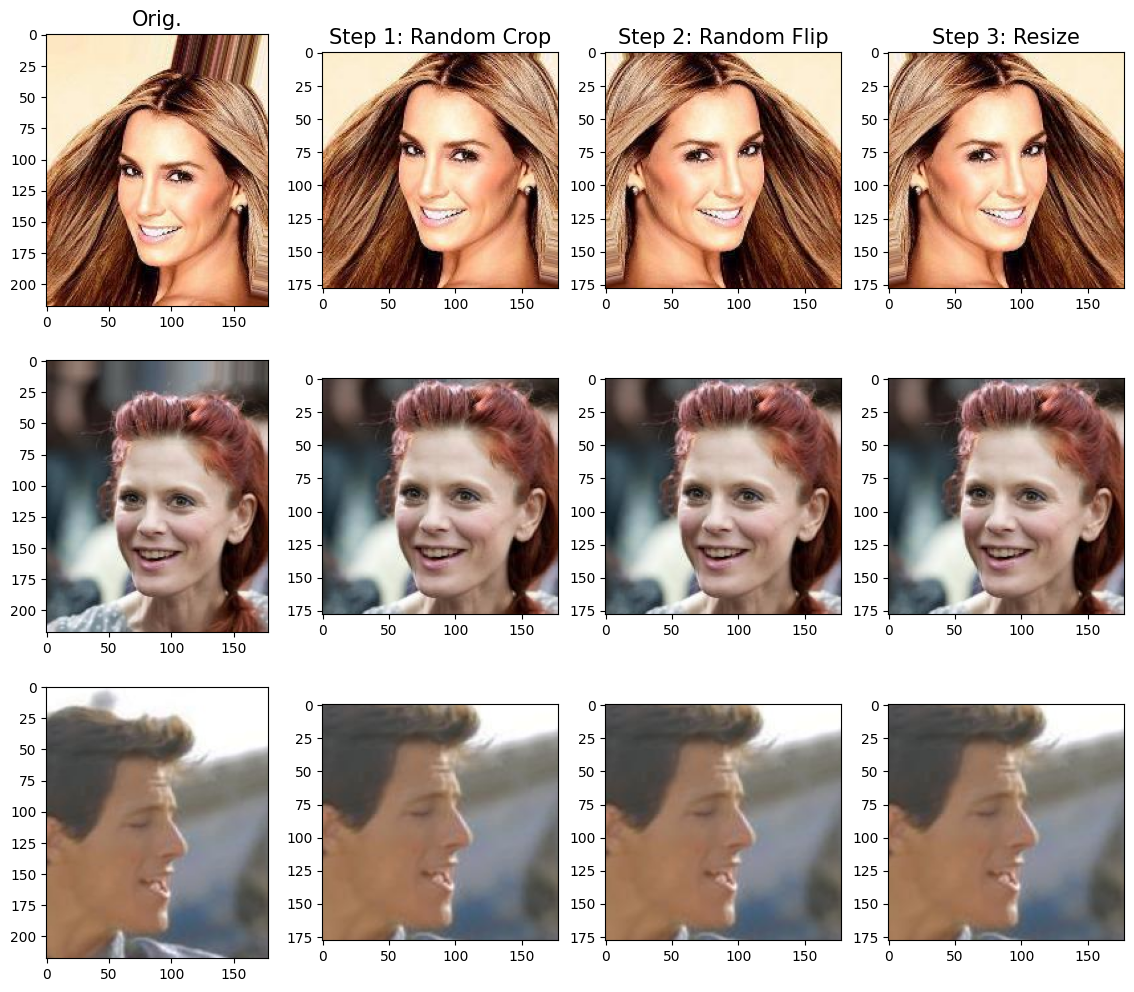

In [ ]:
# Data augmentation using randomized transformations
torch.manual_seed(33)
fig=plt.figure(figsize=(14,12))

for i,(img,attribute) in enumerate(celeba_train_dataset):
    if i<3:
        ax=fig.add_subplot(3,4,i*4+1)
        ax.imshow(img)
        if i==0:
            ax.set_title('Orig.',size=15)
    # Randomized Cropping of an image
        transf1=transforms.Compose([transforms.RandomCrop([178,178])])
        crop_img=transf1(img)
        ax=fig.add_subplot(3,4,i*4+2)
        if i==0:
            ax.set_title('Step 1: Random Crop',size=15)
        ax.imshow(crop_img)
    # Random horizontal flipping
        transf2=transforms.Compose([transforms.RandomHorizontalFlip(p=0.5)])
        flipped_img=transf2(crop_img)
        ax=fig.add_subplot(3,4,i*4+3)
        ax.imshow(flipped_img)
        if i==0:
            ax.set_title('Step 2: Random Flip',size=15)
    # Resizing the image
        resisz_img=transforms.functional.resize(flipped_img,size=(178,178))
        ax=fig.add_subplot(3,4,i*4+4)
        ax.imshow(resisz_img)
        if i==0:
            ax.set_title('Step 3: Resize',size=15)
    # To stop the iterations
    else:
        break
    

In [3]:
# Getting smile
get_smile=lambda attr:attr[18]

In [4]:
# Creating a function to transform the images 
transform_train=transforms.Compose([transforms.RandomCrop([178,178]),transforms.RandomHorizontalFlip(p=0.6),transforms.Resize([64,64]),transforms.ToTensor()])
transform=transforms.Compose([transforms.CenterCrop([178,178]),transforms.Resize([64,64]),transforms.ToTensor()])

In [10]:
os.getcwd()

'c:\\Users\\User\\OneDrive\\Dokumente\\Python Projects\\Raschka ML and DL'

In [13]:
# Applying transformation to test and validation datasets
image_path=r'.'
celeba_train_dataset=torchvision.datasets.CelebA(root=image_path,split='train',target_type='attr',transform=transform_train,target_transform=get_smile,download=False)
celeba_test_dataset=torchvision.datasets.CelebA(root=image_path,split='test',target_type='attr',transform=transform,target_transform=get_smile,download=False)
celeba_valid_dataset=torchvision.datasets.CelebA(root=image_path,split='valid',target_type='attr',transform=transform,target_transform=get_smile,download=False)

In [14]:
# Subseting training/validation dataset (16,000 training and 1,000 validation)
celeba_valid_dataset=Subset(celeba_valid_dataset,torch.arange(1000))
celeba_train_dataset=Subset(celeba_train_dataset,torch.arange(16000))

In [15]:
# Prnting the dataset length
print('Train Dataset Length',len(celeba_train_dataset))
print('Validation Dataset Length',len(celeba_valid_dataset))

Train Dataset Length 16000
Validation Dataset Length 1000


In [16]:
# Creating dataloders
torch.manual_seed(23)
batch_size=32
train_dl=DataLoader(celeba_train_dataset,batch_size=batch_size,shuffle=True)
valid_dl=DataLoader(celeba_valid_dataset,batch_size=batch_size,shuffle=False)
test_dl=DataLoader(celeba_test_dataset,batch_size=batch_size,shuffle=False)

In [17]:
# Creating a model 
model=nn.Sequential()
model.add_module('conv1',nn.Conv2d(in_channels=3,out_channels=32,kernel_size=3,padding=1))
model.add_module('relu1',nn.ReLU())
model.add_module('pool1',nn.MaxPool2d(kernel_size=2))
model.add_module('dropout1',nn.Dropout(p=0.5))
model.add_module('conv2',nn.Conv2d(in_channels=32,out_channels=64,kernel_size=3,padding=1))
model.add_module('relu2',nn.ReLU())
model.add_module('pool2',nn.MaxPool2d(kernel_size=2))
model.add_module('dropout2',nn.Dropout(p=0.5))
model.add_module('conv3',nn.Conv2d(in_channels=64,out_channels=128,kernel_size=3,padding=1))
model.add_module('relu3',nn.ReLU())
model.add_module('pool3',nn.MaxPool2d(kernel_size=2))
model.add_module('conv4',nn.Conv2d(in_channels=128,out_channels=256,kernel_size=3,padding=1))
model.add_module('relu4',nn.ReLU())

In [18]:
# Applying the model on toy image batch
t1=torch.ones((4,3,64,64))
model(t1).shape 

torch.Size([4, 256, 8, 8])

In [19]:
# Conducting average pooling ( 1 value for each feature map)
model.add_module('avg_pool',nn.AvgPool2d(kernel_size=8))
model.add_module('flatten',nn.Flatten())

In [ ]:
# Applying the model to the image batch 
t2=torch.ones((4,3,64,64))
model(t2).shape

torch.Size([4, 256])

In [20]:
# Adding fully connected and sigmoid layer to the model 
model.add_module('fc',nn.Linear(256,1))
model.add_module('sigmoid',nn.Sigmoid())
# Testing the output of the model
t3=torch.ones((4,3,64,64))
model(t3).shape

torch.Size([4, 1])

In [ ]:
# Moving model to device
model.to(device)

Sequential(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout(p=0.5, inplace=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout2): Dropout(p=0.5, inplace=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu3): ReLU()
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu4): ReLU()
  (avg_pool): AvgPool2d(kernel_size=8, stride=8, padding=0)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc): Linear(in_features=256, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

In [21]:
# Specifying the loss function and optimizer
loss_fn=nn.BCELoss()
optimizer=torch.optim.Adam(model.parameters(),lr=0.001)

In [22]:
# Defining the train function for the model 
def train(model,num_epochs,valid_dl,train_dl):
    train_acc=[0]*num_epochs
    train_loss=[0]*num_epochs
    valid_acc=[0]*num_epochs
    valid_loss=[0]*num_epochs
    for epoch in range(num_epochs):
        model.train()
        for x_batch,y_batch in train_dl:
            x_batch=x_batch.to(device)
            y_batch=y_batch.to(device)
            pred=model(x_batch)
            loss=loss_fn(pred.squeeze(),y_batch.float())
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            train_loss[epoch]+=loss.item()
            is_correct=((pred>=0.5).float()==y_batch).float()
            train_acc[epoch]+=is_correct.mean()
        # Dividing through the length of the dataset to determine the accuracy as proportion
        train_acc[epoch]/=len(train_dl)
        # Determining the average loss per batch 
        train_loss[epoch]/=len(train_dl)
    # Conducting the evaluation   
        with torch.no_grad():
            model.eval()
            for x_batch,y_batch in valid_dl:
                x_batch=x_batch.to(device)
                y_batch=y_batch.to(device)
                # Predicting the results on the validation batch
                pred=model(x_batch)
                loss=loss_fn(pred.squeeze(),y_batch.float())
                # Storing the validation loss
                valid_loss[epoch]+=loss.item()
                # Determining accuracy and storing validation accuracy
                is_correct=((pred>=0.5).float()==y_batch).float()
                valid_acc[epoch]+=is_correct.mean()
            # Dividing accuracy through length to get it as proportion 
            valid_acc[epoch]/=len(valid_dl)
            # Dividing loss through the number of batches to get average loss per batch 
            valid_loss[epoch]/=len(valid_dl)
        # Printing accuracy per epoch 
        print(f'Epoch {epoch+1},\tTrain Acc: {train_acc[epoch]:.4f},\tValid Acc: {valid_acc[epoch]:.4f}')
    return train_loss,valid_loss,train_acc,valid_acc 


In [23]:
# Training the model 
torch.manual_seed(11)
num_epochs=50
loss_train,loss_val,acc_train,acc_val=train(model,num_epochs=num_epochs,valid_dl=valid_dl,train_dl=train_dl) 

Epoch 1,	Train Acc: 0.6077,	Valid Acc: 0.5577
Epoch 2,	Train Acc: 0.5507,	Valid Acc: 0.5298
Epoch 3,	Train Acc: 0.5438,	Valid Acc: 0.5444
Epoch 4,	Train Acc: 0.5434,	Valid Acc: 0.5432
Epoch 5,	Train Acc: 0.5425,	Valid Acc: 0.5217
Epoch 6,	Train Acc: 0.5398,	Valid Acc: 0.5181
Epoch 7,	Train Acc: 0.5396,	Valid Acc: 0.5209
Epoch 8,	Train Acc: 0.5410,	Valid Acc: 0.5255
Epoch 9,	Train Acc: 0.5386,	Valid Acc: 0.5281
Epoch 10,	Train Acc: 0.5399,	Valid Acc: 0.5186
Epoch 11,	Train Acc: 0.5377,	Valid Acc: 0.5236
Epoch 12,	Train Acc: 0.5398,	Valid Acc: 0.5305
Epoch 13,	Train Acc: 0.5365,	Valid Acc: 0.5137
Epoch 14,	Train Acc: 0.5369,	Valid Acc: 0.5172
Epoch 15,	Train Acc: 0.5380,	Valid Acc: 0.5234
Epoch 16,	Train Acc: 0.5370,	Valid Acc: 0.5198
Epoch 17,	Train Acc: 0.5376,	Valid Acc: 0.5197
Epoch 18,	Train Acc: 0.5355,	Valid Acc: 0.5234
Epoch 19,	Train Acc: 0.5365,	Valid Acc: 0.5280
Epoch 20,	Train Acc: 0.5373,	Valid Acc: 0.5243
Epoch 21,	Train Acc: 0.5362,	Valid Acc: 0.5178
Epoch 22,	Train Acc: 0

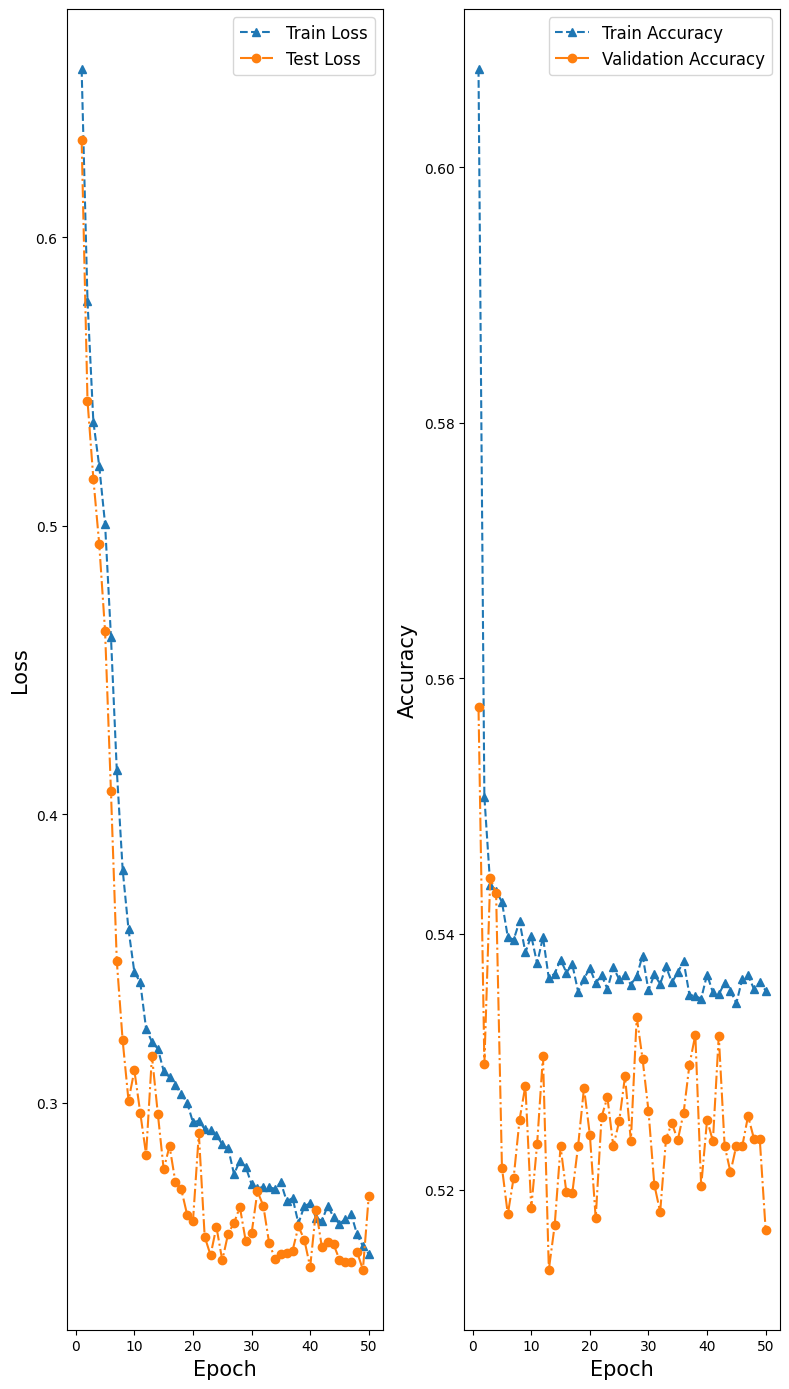

In [36]:
# Plotting loss as well as accuracy for both train and validation parts
fig=plt.figure(figsize=(8,14))
ax=fig.add_subplot(1,2,1)
ax.plot(np.arange(1,len(loss_train)+1),loss_train,marker='^',ls='--',label='Train Loss')
ax.plot(np.arange(1,len(loss_val)+1),loss_val,marker='o',ls='-.',label='Test Loss')
plt.legend(loc='upper right',fontsize=12)
plt.xlabel('Epoch',size=15)
plt.ylabel('Loss',size=15)
ax=fig.add_subplot(1,2,2)
ax.plot(np.arange(1,len(acc_train)+1),acc_train,marker='^',ls='--',label='Train Accuracy')
ax.plot(np.arange(1,len(acc_val)+1),acc_val,marker='o',ls='-.',label='Validation Accuracy')
plt.legend(loc='upper right',fontsize=12)
plt.xlabel('Epoch',size=15)
plt.ylabel('Accuracy',size=15)
plt.tight_layout()

In [39]:
# Evaluating the model on the test dataset
model.eval()
accuracy_test=0
with torch.no_grad():
    for x_batch,y_batch in test_dl:
        pred=model(x_batch)
        is_correct=((pred>=0.5).float()==y_batch).float()
        accuracy_test+=is_correct.sum()
    accuracy_test/=len(test_dl.dataset)
print(f'Accuracy Test {accuracy_test:.4f}')


Accuracy Test 16.3953
